<a href="https://colab.research.google.com/github/grullaandrea-png/Deep_Learning/blob/main/Progetto_Finale_Res_net18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Cancella la cartella dataset se è incasinata
!rm -rf /content/dataset
# Crea una cartella pulita
!mkdir /content/dataset
# Copia il CONTENUTO della tua cartella Drive dentro /content/dataset
!cp -r /content/drive/MyDrive/Deep_learning/. /content/dataset/

#***Exploratory Analysis***
***

In [ ]:
import os

data_dir = '/content/dataset'
print("Classes found:", os.listdir(data_dir))

# where data are estracted
dataset_path = '/content/dataset'

conteggi = {}

if os.path.exists(dataset_path):
    # all class folders
    classi = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for classe in classi:
        path_classe = os.path.join(dataset_path, classe)
        n_imagins = len(os.listdir(path_classe))
        conteggi[classe] = n_imagins
        print(f"Class: {classe:<20} | Imagins: {n_imagins}")

    print("-" * 40)
    print(f"Total imagins: {sum(conteggi.values())}")
else:
    print("Error: folder doesn't found")

Classes found: ['Amanita', 'Suillus', 'Entoloma', 'Cortinarius', 'Lactarius', 'Hygrocybe', 'Boletus', 'Exidia', 'Agaricus', 'Russula', 'Inocybe', 'Pluteus']
Class: Amanita              | Imagins: 1000
Class: Suillus              | Imagins: 1000
Class: Entoloma             | Imagins: 1000
Class: Cortinarius          | Imagins: 1000
Class: Lactarius            | Imagins: 1000
Class: Hygrocybe            | Imagins: 1000
Class: Boletus              | Imagins: 1000
Class: Exidia               | Imagins: 1000
Class: Agaricus             | Imagins: 1000
Class: Russula              | Imagins: 1000
Class: Inocybe              | Imagins: 1000
Class: Pluteus              | Imagins: 1000
----------------------------------------
Total imagins: 12000


Classes: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Exidia', 'Hygrocybe', 'Inocybe', 'Lactarius', 'Pluteus', 'Russula', 'Suillus']


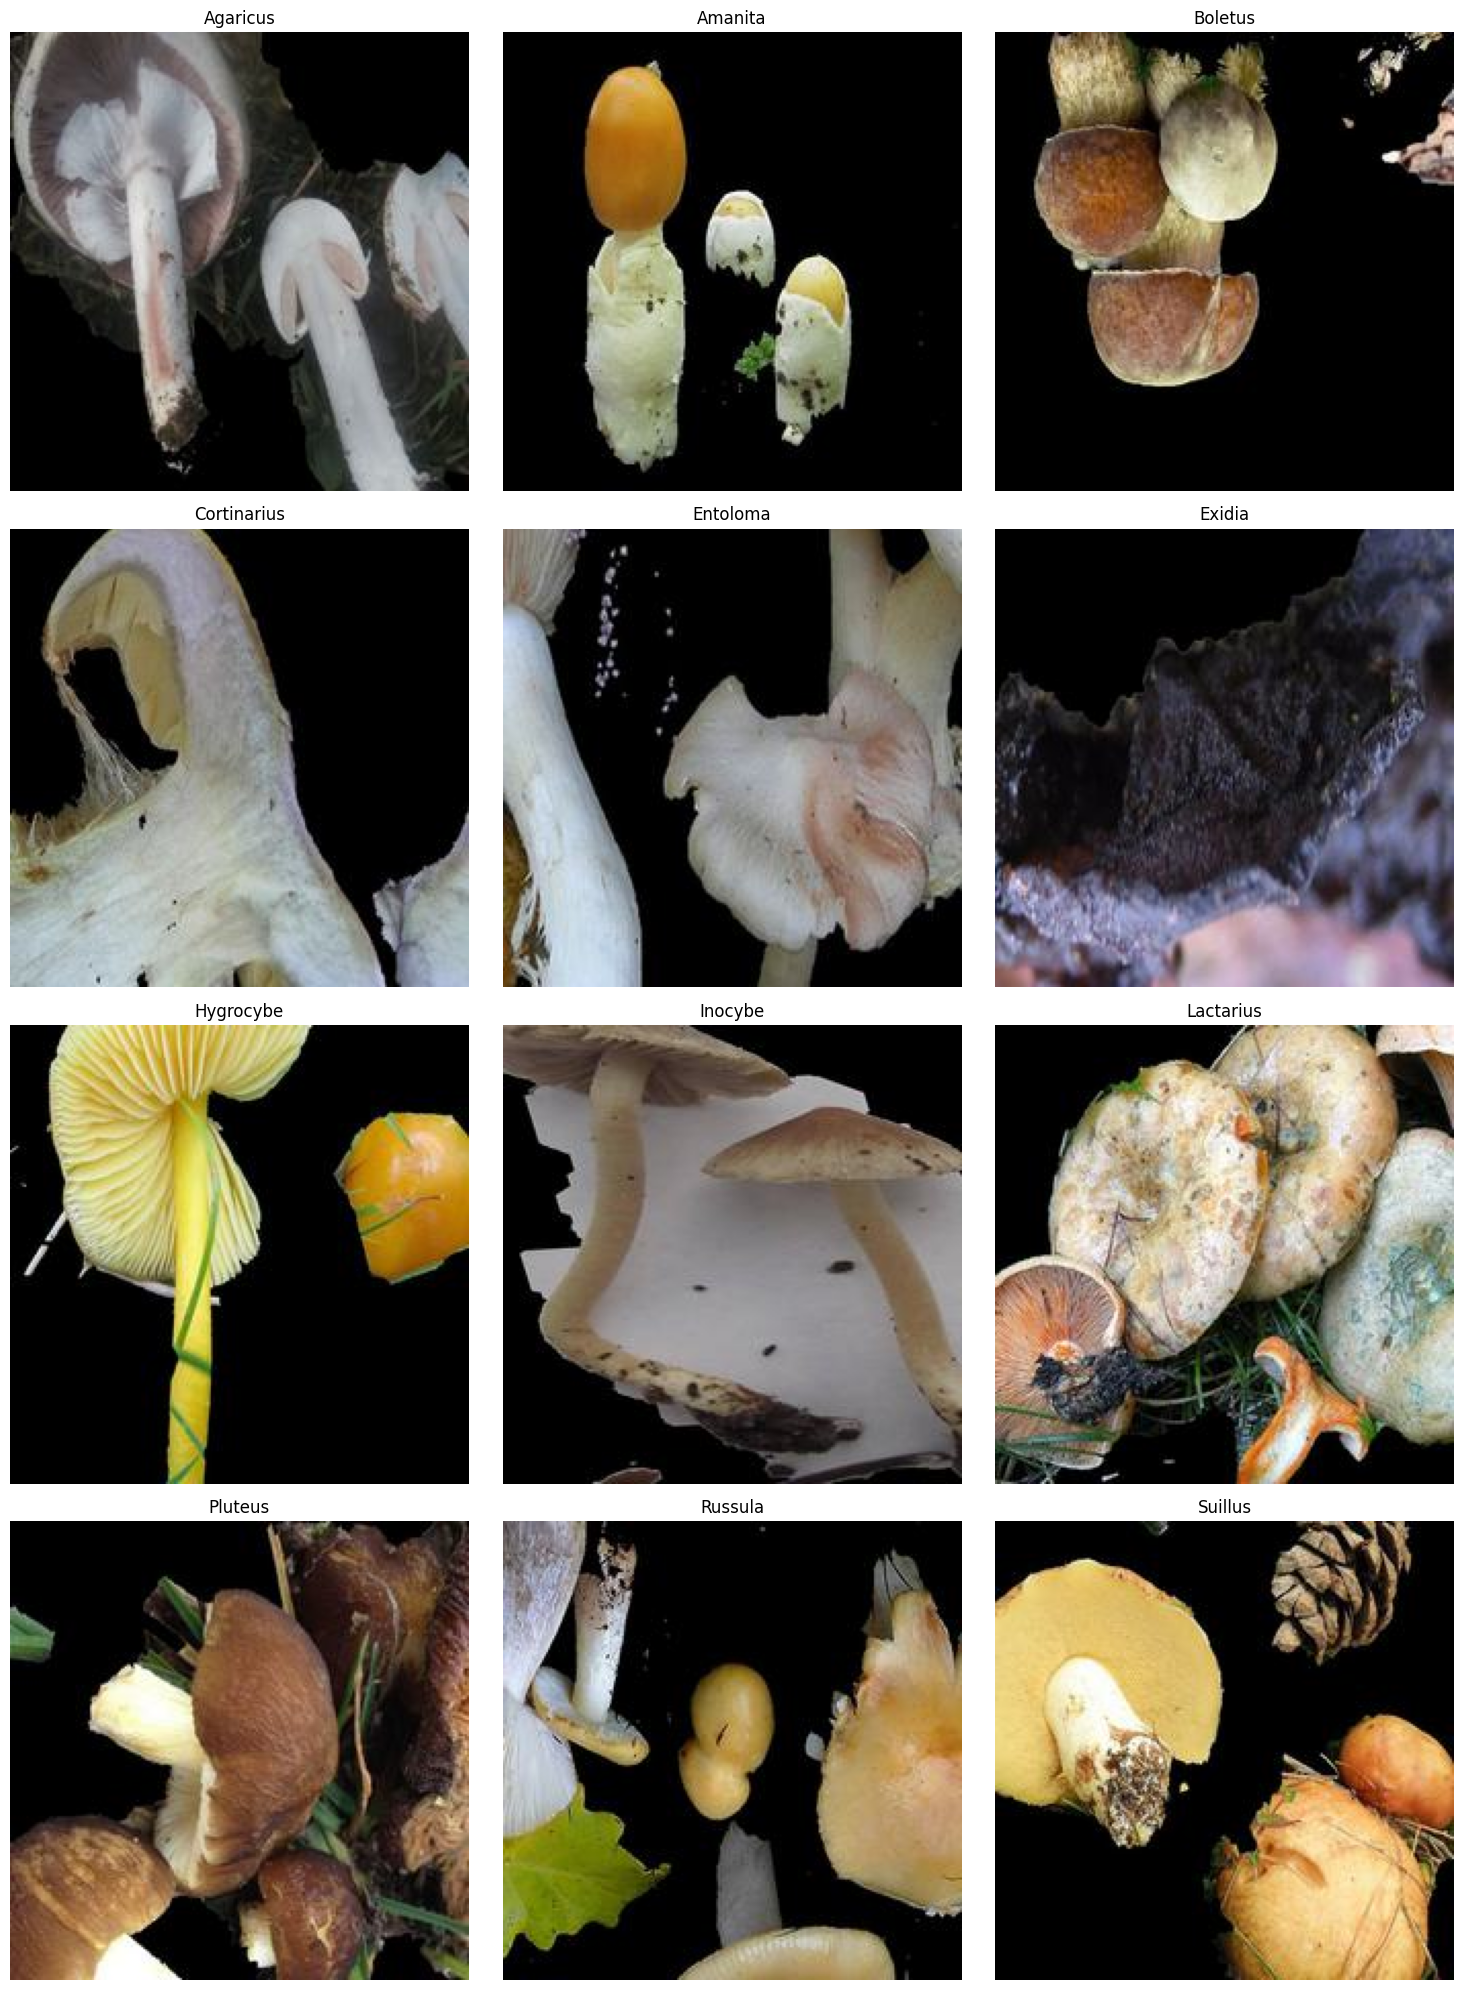

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

class_names = full_dataset.classes
print(f"Classes: {class_names}")

num_classes = len(class_names)
cols = 3
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(15, 5 * rows))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)

    if os.path.isdir(class_folder):
        files = os.listdir(class_folder)
        if len(files) > 0:
            img_path = os.path.join(class_folder, files[0])

            img = Image.open(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

plt.tight_layout()
plt.show()

## **MODEL 2: RESNET.18**



***
After completing the optimization and augmentation steps on the AlexNet-based approach, we move to a more modern convolutional architecture, ResNet18, to evaluate how a different network design affects performance on the same classification task. The goal of this phase is to understand what changes when using a deeper architecture with residual connections, and whether this leads to improved feature extraction and generalization compared to the previous model family.

The full ResNet18 model follows the standard structure: an initial “stem” (7×7 convolution, BatchNorm, ReLU, max pooling), followed by four stages of residual blocks with channel sizes 64, 128, 256, and 512. Downsampling is performed by using stride 2 at the beginning of layers 2–4. Finally, the network applies adaptive average pooling, flattens the features, and maps them to the final class scores through a fully connected layer.

To establish a fair baseline comparison, the training pipeline remains consistent with previous experiments: we use the same evaluation function on GPU, the same loss function (cross-entropy), and a standard optimizer configuration (SGD with fixed learning rate) without momentum or scheduling. This baseline setup allows us to observe the raw learning behaviour of ResNet18 before introducing further optimization and training refinements in subsequent steps.
***

### **MODEL 2:A - Baseline model**
***



We partitioned the dataset into training, validation, and test sets (70/10/20) to ensure a controlled and reproducible evaluation pipeline.
We implemented a data augmentation and normalization strategy via DataLoaders to enhance model generalization and optimize training efficiency.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


data_dir = '/content/dataset'
batch_size = 32
img_height, img_width = 224, 224

data_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)

# Compute dimension for the split (70% - 10% - 20%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size
print(f"Total images: {total_size}")
print(f"Training: {train_size} | Validation: {val_size} | Test: {test_size}")





data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset
import copy

# dataset without trasformations
full_dataset = ImageFolder(root='/content/dataset')

# casual division
generator = torch.Generator().manual_seed(42)
train_indices, val_indices, test_indices = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Define a small class for compute the specific transformation
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Apply the trasformations
train_dataset = ApplyTransform(train_indices, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_indices, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_indices, transform=data_transforms['val']) # Test usa le stesse di Val

# Create the DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### print("DataLoader created successfully!")

Total images: 12000
Training: 8400 | Validation: 1200 | Test: 2400


In [ ]:
import torch
import torch.nn as nn
from torchvision import models


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class BasicBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # Prima convoluzione
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Seconda convoluzione
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)

        # Shortcut connection (Connessione residua)
        self.shortcut = nn.Sequential()
        # Se le dimensioni spaziali o il numero di canali cambiano, usiamo una Conv 1x1 per allinearli
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x) # Salviamo l'input per la skip connection

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity             # Sommiamo l'input elaborato alla skip connection
        out = self.relu(out)
        out = self.se(out)

        return out

class ResNet18Custom(nn.Module):
    def __init__(self, num_classes=12): # 12 classi per i funghi
        super(ResNet18Custom, self).__init__()
        self.in_channels = 64

        # 1. Livello iniziale (Stem)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 2. Layers della ResNet (nella ResNet18 ci sono 2 blocchi per ogni layer)
        self.layer1 = self._make_layer(64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        # 3. Classificatore finale
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        # AGGIUNTA: Inizializzazione scientifica dei pesi (He Initialization)
        # Aiuta il modello a convergere più velocemente partendo da zero
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                # Controllo: inizializza il bias SOLO se esiste
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                # Anche le Linear potrebbero teoricamente non avere il bias
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, num_blocks, stride):
        # Il primo blocco può avere uno stride > 1, i successivi hanno sempre stride 1
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels # Aggiorniamo in_channels per il blocco successivo
        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# Come richiamarla nel tuo training script:
# model = ResNet18Custom(num_classes=12)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes) # Assicurati che full_dataset sia definito

# Create the model
model = ResNet18Custom(num_classes=num_classes)
model = model.to(device)

print(f"Model MushroomResNet uploaded on {device} for {num_classes} classes.")

Model MushroomResNet uploaded on cuda for 12 classes.


The model utilizes He initialization to stabilize training from random weights and is fully optimized for GPU execution on our 12-class classification task.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        out = self.se(out)
        return out

class ResNet18Custom(nn.Module):
    def __init__(self, num_classes=12):
        super(ResNet18Custom, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2, 1)
        self.layer2 = self._make_layer(128, 2, 2)
        self.layer3 = self._make_layer(256, 2, 2)
        self.layer4 = self._make_layer(512, 2, 2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

        # FIX: Inizializzazione corretta con controllo sui bias
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# Inizializzazione modello
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 12 # Imposta il numero delle tue classi di funghi

model = ResNet18Custom(num_classes=num_classes).to(device)
print(f"Modello pronto su {device}")

Modello pronto su cuda


We used the Adam optimizer and CrossEntropyLoss to efficiently minimize classification error using adaptive gradients and weight decay regularization.
The ReduceLROnPlateau scheduler was implemented to automatically lower the learning rate when the validation loss stagnates, allowing the model to overcome plateaus and achieve better convergence.

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device used is: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4) # Learning rate

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3,
)

#***Model Train Start***

Start the train on cuda...
The best model would be saved on: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth
Epoch [1/30] | Train Loss: 2.0728 | Val Loss: 1.9593 | Val Acc: 32.42%
--> Improvement! Model saving... (Accuracy: 0.00% -> 32.42%)
Epoch [2/30] | Train Loss: 2.0223 | Val Loss: 1.9387 | Val Acc: 33.08%
--> Improvement! Model saving... (Accuracy: 32.42% -> 33.08%)
Epoch [3/30] | Train Loss: 1.9769 | Val Loss: 2.0365 | Val Acc: 31.92%
Epoch [4/30] | Train Loss: 1.9295 | Val Loss: 1.7724 | Val Acc: 39.92%
--> Improvement! Model saving... (Accuracy: 33.08% -> 39.92%)
Epoch [5/30] | Train Loss: 1.8985 | Val Loss: 1.7819 | Val Acc: 40.67%
--> Improvement! Model saving... (Accuracy: 39.92% -> 40.67%)


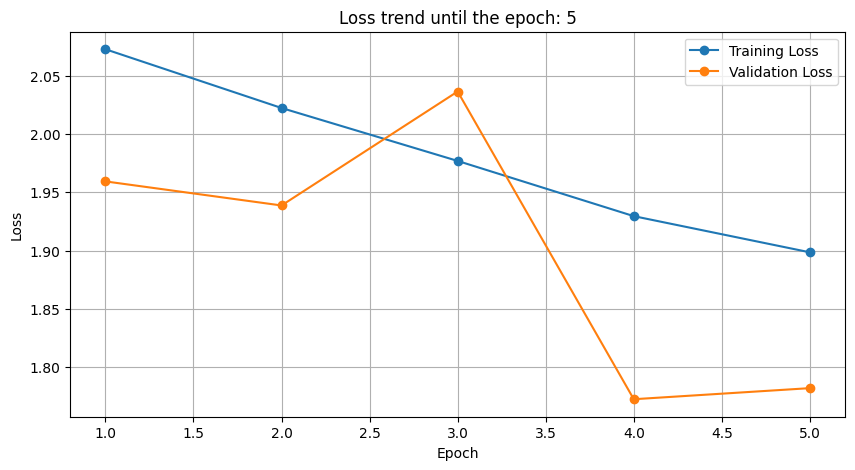

Epoch [6/30] | Train Loss: 1.8659 | Val Loss: 1.7670 | Val Acc: 40.83%
--> Improvement! Model saving... (Accuracy: 40.67% -> 40.83%)
Epoch [7/30] | Train Loss: 1.8294 | Val Loss: 1.6692 | Val Acc: 42.83%
--> Improvement! Model saving... (Accuracy: 40.83% -> 42.83%)
Epoch [8/30] | Train Loss: 1.7851 | Val Loss: 1.6342 | Val Acc: 43.75%
--> Improvement! Model saving... (Accuracy: 42.83% -> 43.75%)
Epoch [9/30] | Train Loss: 1.7626 | Val Loss: 1.6769 | Val Acc: 43.17%
Epoch [10/30] | Train Loss: 1.7428 | Val Loss: 1.5876 | Val Acc: 44.25%
--> Improvement! Model saving... (Accuracy: 43.75% -> 44.25%)


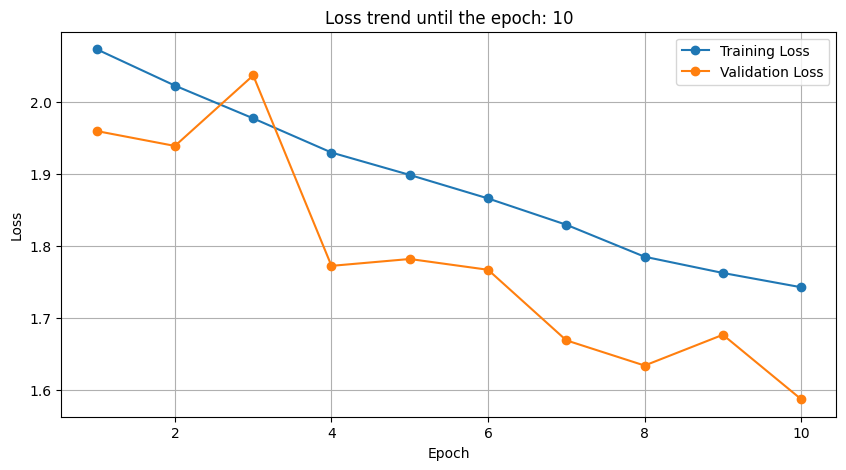

Epoch [11/30] | Train Loss: 1.7126 | Val Loss: 1.5647 | Val Acc: 45.92%
--> Improvement! Model saving... (Accuracy: 44.25% -> 45.92%)
Epoch [12/30] | Train Loss: 1.6984 | Val Loss: 1.5342 | Val Acc: 46.50%
--> Improvement! Model saving... (Accuracy: 45.92% -> 46.50%)
Epoch [13/30] | Train Loss: 1.6639 | Val Loss: 1.6878 | Val Acc: 44.58%
Epoch [14/30] | Train Loss: 1.6426 | Val Loss: 1.5185 | Val Acc: 48.00%
--> Improvement! Model saving... (Accuracy: 46.50% -> 48.00%)
Epoch [15/30] | Train Loss: 1.6168 | Val Loss: 1.6437 | Val Acc: 46.33%


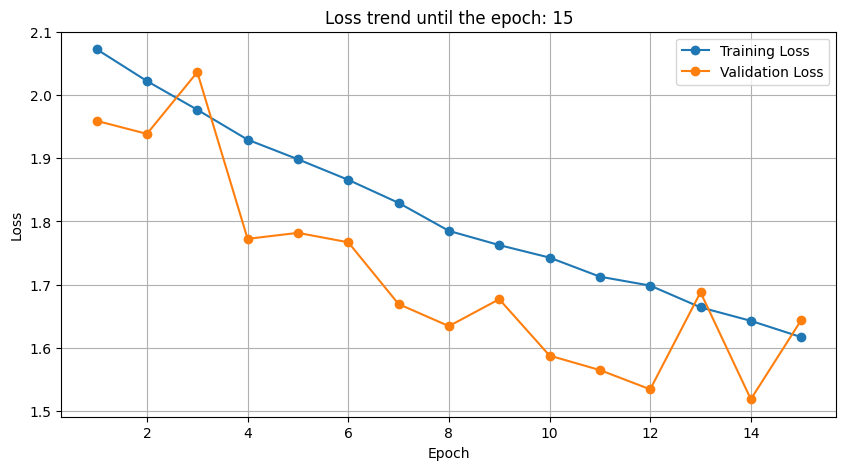

Epoch [16/30] | Train Loss: 1.5923 | Val Loss: 1.4851 | Val Acc: 50.00%
--> Improvement! Model saving... (Accuracy: 48.00% -> 50.00%)
Epoch [17/30] | Train Loss: 1.5907 | Val Loss: 1.4868 | Val Acc: 49.33%
Epoch [18/30] | Train Loss: 1.5637 | Val Loss: 1.4482 | Val Acc: 52.50%
--> Improvement! Model saving... (Accuracy: 50.00% -> 52.50%)
Epoch [19/30] | Train Loss: 1.5336 | Val Loss: 1.4860 | Val Acc: 49.58%
Epoch [20/30] | Train Loss: 1.5240 | Val Loss: 1.3343 | Val Acc: 55.75%
--> Improvement! Model saving... (Accuracy: 52.50% -> 55.75%)


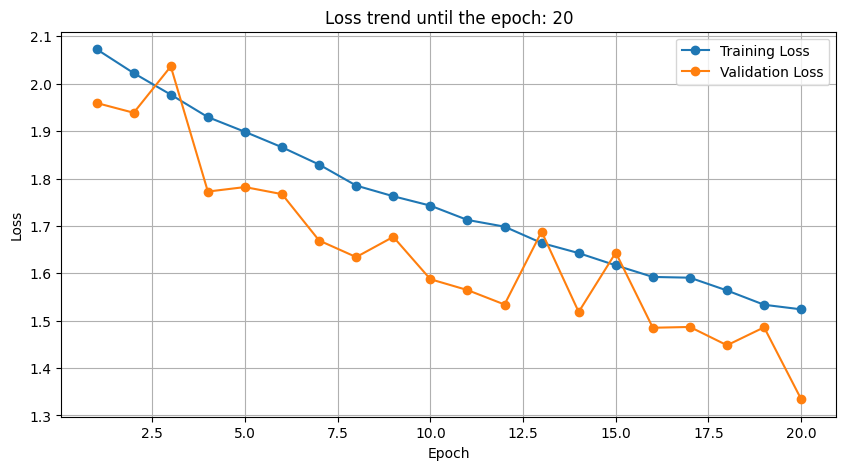

Epoch [21/30] | Train Loss: 1.4982 | Val Loss: 1.3557 | Val Acc: 53.67%
Epoch [22/30] | Train Loss: 1.4800 | Val Loss: 1.3952 | Val Acc: 53.25%
Epoch [23/30] | Train Loss: 1.4345 | Val Loss: 1.3115 | Val Acc: 55.58%
Epoch [24/30] | Train Loss: 1.4384 | Val Loss: 1.3311 | Val Acc: 56.33%
--> Improvement! Model saving... (Accuracy: 55.75% -> 56.33%)
Epoch [25/30] | Train Loss: 1.4103 | Val Loss: 1.3073 | Val Acc: 57.42%
--> Improvement! Model saving... (Accuracy: 56.33% -> 57.42%)


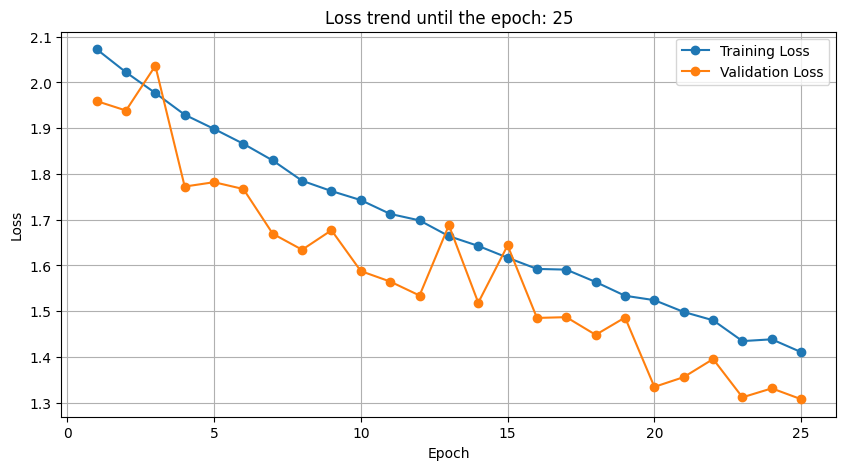

Epoch [26/30] | Train Loss: 1.4008 | Val Loss: 1.2799 | Val Acc: 56.83%
Epoch [27/30] | Train Loss: 1.3904 | Val Loss: 1.4531 | Val Acc: 52.92%
Epoch [28/30] | Train Loss: 1.3548 | Val Loss: 1.2636 | Val Acc: 59.25%
--> Improvement! Model saving... (Accuracy: 57.42% -> 59.25%)
Epoch [29/30] | Train Loss: 1.3393 | Val Loss: 1.2596 | Val Acc: 59.92%
--> Improvement! Model saving... (Accuracy: 59.25% -> 59.92%)
Epoch [30/30] | Train Loss: 1.3284 | Val Loss: 1.2262 | Val Acc: 60.00%
--> Improvement! Model saving... (Accuracy: 59.92% -> 60.00%)


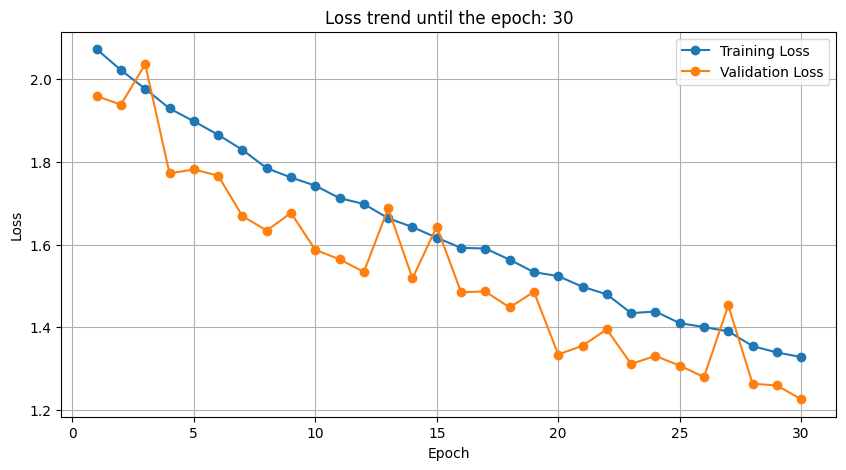

------------------------------
Trained completed! Best accuracy reached: 60.00%
Model saved in: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth


In [ ]:
import matplotlib.pyplot as plt
import torch
import os
import torch.optim as optim
from IPython.display import clear_output

folder_path = '/content/drive/MyDrive/Deep_learning'
save_path = os.path.join(folder_path, 'best_mushroom_model.pth')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
best_val_acc = 0.0
train_losses = []
val_losses = []

num_epochs = 30

print(f"Start the train on {device}...")
print(f"The best model would be saved on: {save_path}")


# TRAIN
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

  # VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    # PLOT
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")

#***Model 2B***
***Transform and Optimezer***
***

We refined the augmentation strategy by increasing rotation and color jitter while restricting crop scale to ensure the mushroom remains the central feature in every image.
This domain-specific tuning improved the model's robustness against background noise and varied lighting conditions, leading to better generalization and a measurable increase in accuracy.

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30), # Fondamentale per i funghi
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

We transitioned to AdamW to decouple weight decay from the optimization step, resulting in more mathematically correct and effective regularization. This modification prevents overfitting more efficiently than standard Adam, leading to improved generalization on our mushroom dataset.

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device used is: {device}")

model = model.to(device)

# La Loss rimane invariata
criterion = nn.CrossEntropyLoss()

# Optimizer AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.01
)

# Scheduler corretto (senza verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

The device used is: cuda


#***Model Train Start***

Start the train on cuda...
The best model would be saved on: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth
Epoch [1/30] | Train Loss: 2.2587 | Val Loss: 2.0738 | Val Acc: 29.50%
--> Improvement! Model saving... (Accuracy: 0.00% -> 29.50%)
Epoch [2/30] | Train Loss: 2.1016 | Val Loss: 2.0003 | Val Acc: 29.17%
Epoch [3/30] | Train Loss: 2.0236 | Val Loss: 2.0115 | Val Acc: 27.50%
Epoch [4/30] | Train Loss: 1.9476 | Val Loss: 1.9473 | Val Acc: 31.33%
--> Improvement! Model saving... (Accuracy: 29.50% -> 31.33%)
Epoch [5/30] | Train Loss: 1.8865 | Val Loss: 1.9022 | Val Acc: 33.33%
--> Improvement! Model saving... (Accuracy: 31.33% -> 33.33%)


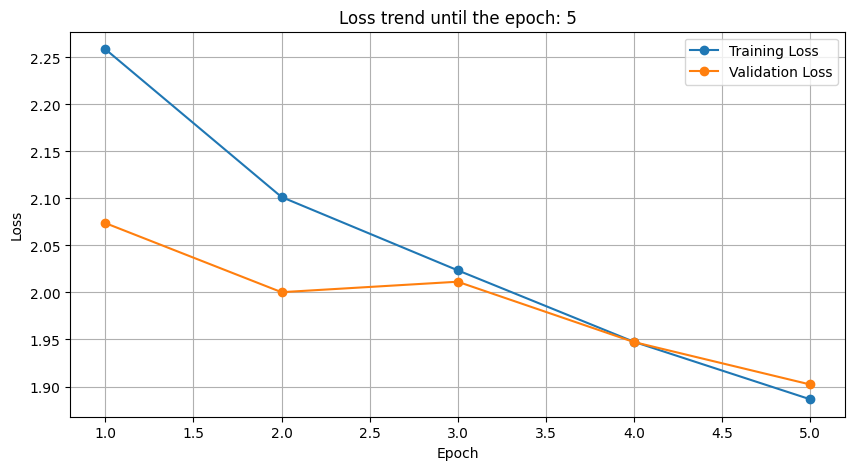

Epoch [6/30] | Train Loss: 1.8128 | Val Loss: 1.8235 | Val Acc: 38.08%
--> Improvement! Model saving... (Accuracy: 33.33% -> 38.08%)
Epoch [7/30] | Train Loss: 1.7698 | Val Loss: 1.7369 | Val Acc: 43.42%
--> Improvement! Model saving... (Accuracy: 38.08% -> 43.42%)
Epoch [8/30] | Train Loss: 1.7273 | Val Loss: 1.6826 | Val Acc: 41.33%
Epoch [9/30] | Train Loss: 1.6747 | Val Loss: 1.6797 | Val Acc: 42.00%
Epoch [10/30] | Train Loss: 1.6383 | Val Loss: 1.6221 | Val Acc: 44.83%
--> Improvement! Model saving... (Accuracy: 43.42% -> 44.83%)


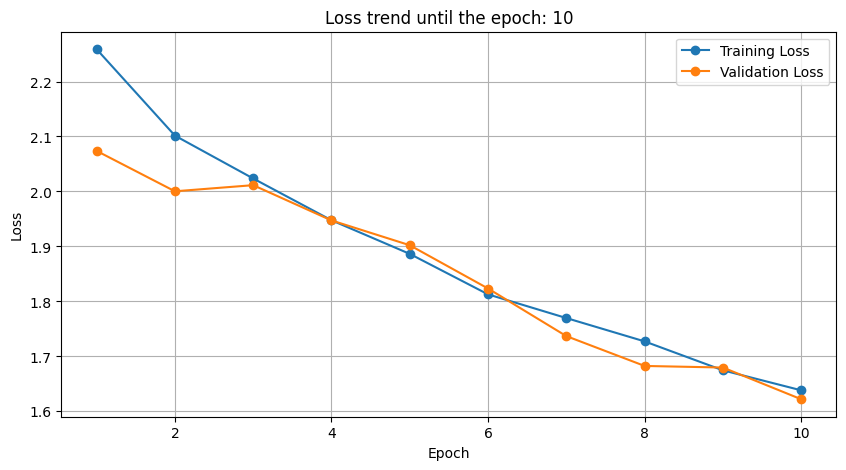

Epoch [11/30] | Train Loss: 1.5917 | Val Loss: 1.5628 | Val Acc: 46.75%
--> Improvement! Model saving... (Accuracy: 44.83% -> 46.75%)
Epoch [12/30] | Train Loss: 1.5575 | Val Loss: 1.5656 | Val Acc: 48.58%
--> Improvement! Model saving... (Accuracy: 46.75% -> 48.58%)
Epoch [13/30] | Train Loss: 1.5094 | Val Loss: 1.5012 | Val Acc: 48.92%
--> Improvement! Model saving... (Accuracy: 48.58% -> 48.92%)
Epoch [14/30] | Train Loss: 1.4713 | Val Loss: 1.4196 | Val Acc: 50.92%
--> Improvement! Model saving... (Accuracy: 48.92% -> 50.92%)
Epoch [15/30] | Train Loss: 1.4281 | Val Loss: 1.4397 | Val Acc: 50.33%


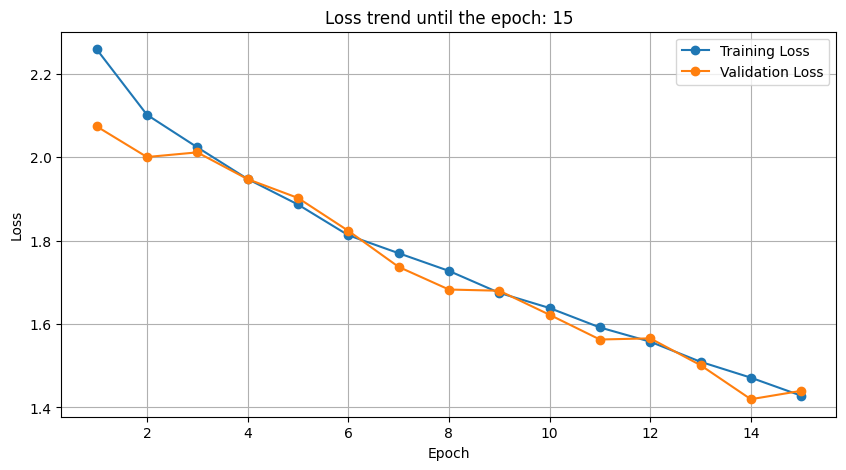

Epoch [16/30] | Train Loss: 1.3907 | Val Loss: 1.3918 | Val Acc: 52.67%
--> Improvement! Model saving... (Accuracy: 50.92% -> 52.67%)
Epoch [17/30] | Train Loss: 1.3557 | Val Loss: 1.3781 | Val Acc: 53.50%
--> Improvement! Model saving... (Accuracy: 52.67% -> 53.50%)
Epoch [18/30] | Train Loss: 1.3128 | Val Loss: 1.3239 | Val Acc: 55.00%
--> Improvement! Model saving... (Accuracy: 53.50% -> 55.00%)
Epoch [19/30] | Train Loss: 1.2892 | Val Loss: 1.3382 | Val Acc: 56.33%
--> Improvement! Model saving... (Accuracy: 55.00% -> 56.33%)
Epoch [20/30] | Train Loss: 1.2463 | Val Loss: 1.3316 | Val Acc: 55.75%


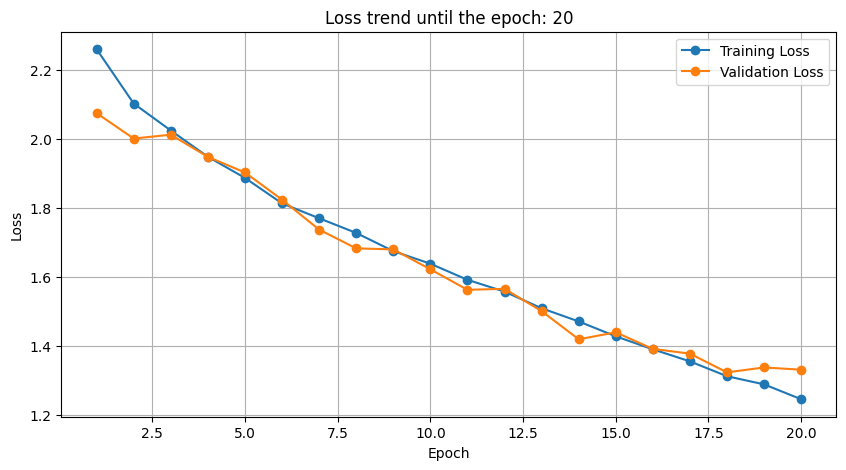

Epoch [21/30] | Train Loss: 1.2149 | Val Loss: 1.2921 | Val Acc: 59.08%
--> Improvement! Model saving... (Accuracy: 56.33% -> 59.08%)
Epoch [22/30] | Train Loss: 1.1956 | Val Loss: 1.3425 | Val Acc: 57.17%
Epoch [23/30] | Train Loss: 1.1603 | Val Loss: 1.2930 | Val Acc: 57.25%
Epoch [24/30] | Train Loss: 1.1145 | Val Loss: 1.3581 | Val Acc: 54.33%
Epoch [25/30] | Train Loss: 1.1095 | Val Loss: 1.2591 | Val Acc: 57.17%


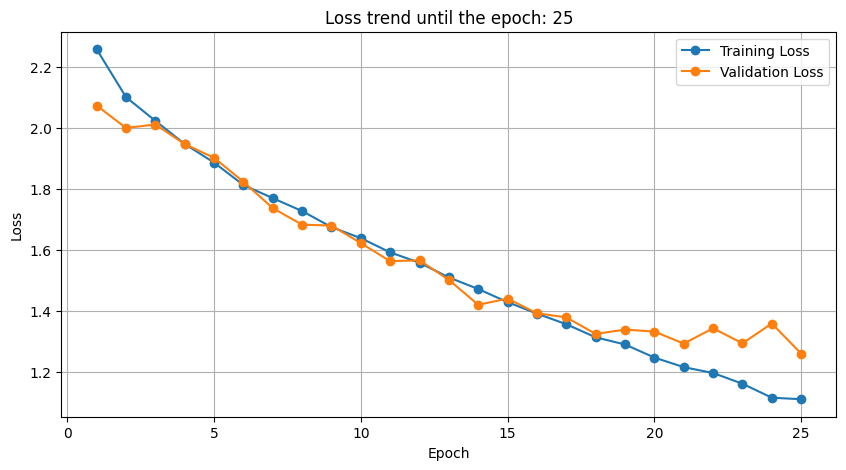

Epoch [26/30] | Train Loss: 1.0553 | Val Loss: 1.2315 | Val Acc: 57.00%
Epoch [27/30] | Train Loss: 1.0375 | Val Loss: 1.1460 | Val Acc: 61.33%
--> Improvement! Model saving... (Accuracy: 59.08% -> 61.33%)
Epoch [28/30] | Train Loss: 1.0035 | Val Loss: 1.2798 | Val Acc: 58.67%
Epoch [29/30] | Train Loss: 0.9930 | Val Loss: 1.2824 | Val Acc: 59.33%
Epoch [30/30] | Train Loss: 0.9583 | Val Loss: 1.0449 | Val Acc: 65.92%
--> Improvement! Model saving... (Accuracy: 61.33% -> 65.92%)


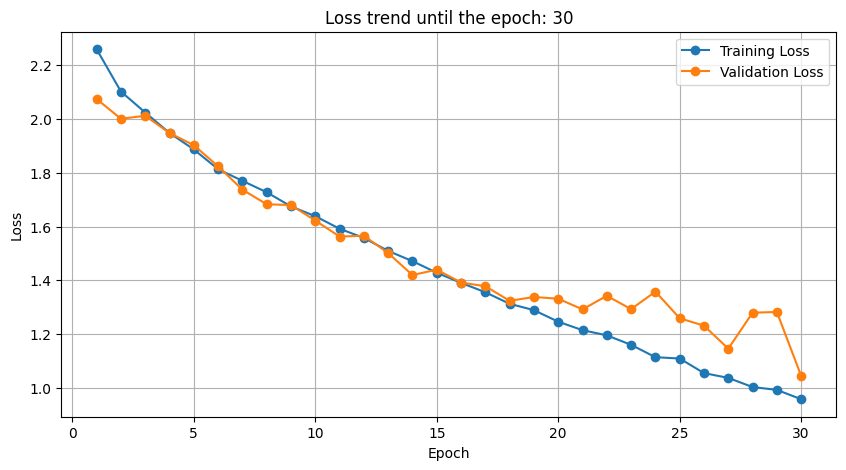

------------------------------
Trained completed! Best accuracy reached: 65.92%
Model saved in: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth


In [ ]:
import matplotlib.pyplot as plt
import torch
import os
import torch.optim as optim
from IPython.display import clear_output

folder_path = '/content/drive/MyDrive/Deep_learning'
save_path = os.path.join(folder_path, 'best_mushroom_model.pth')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
best_val_acc = 0.0
train_losses = []
val_losses = []

num_epochs = 30

print(f"Start the train on {device}...")
print(f"The best model would be saved on: {save_path}")


# TRAIN
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

  # VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    # PLOT
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")

#***Model 2C***
***RandomErasing , Scheduler and Epoch***
***

We implemented Random Erasing to simulate natural occlusions like leaves or debris, forcing the model to learn global features rather than relying on single specific details.

This regularization technique prevents the network from overfitting on local patterns and improves its ability to recognize mushrooms even when they are partially hidden in their natural environment.

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30), # Fondamentale per i funghi
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),   # We add this code part
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


We upgraded to  CosineAnnealingLR to ensure a smoother, more stable convergence throughout the training process.
Training was extended to 60 epochs to allow the network sufficient time to learn from the increased data complexity introduced by Random Erasing.

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device used is: {device}")

model = model.to(device)

# La Loss rimane invariata
criterion = nn.CrossEntropyLoss()

# Optimizer AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-5
)
num_epochs = 60   # We change the epoch
# 2. CAMBIATO SCHEDULER: Usa CosineAnnealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(   # We change the schedaleur
    optimizer,
    T_max=num_epochs, # Arriva al minimo esattamente alla fine delle 50 epoche
    eta_min=1e-6      # LR minimo a cui arriverà
)

The device used is: cuda


#***Model Train Start***

Start the train on cuda...
The best model would be saved on: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth
Epoch [1/60] | Train Loss: 2.2609 | Val Loss: 2.0867 | Val Acc: 27.25%
--> Improvement! Model saving... (Accuracy: 0.00% -> 27.25%)
Epoch [2/60] | Train Loss: 2.1211 | Val Loss: 2.0144 | Val Acc: 30.00%
--> Improvement! Model saving... (Accuracy: 27.25% -> 30.00%)
Epoch [3/60] | Train Loss: 2.0258 | Val Loss: 2.0006 | Val Acc: 30.08%
--> Improvement! Model saving... (Accuracy: 30.00% -> 30.08%)
Epoch [4/60] | Train Loss: 1.9655 | Val Loss: 1.9070 | Val Acc: 34.42%
--> Improvement! Model saving... (Accuracy: 30.08% -> 34.42%)
Epoch [5/60] | Train Loss: 1.9126 | Val Loss: 1.8441 | Val Acc: 36.92%
--> Improvement! Model saving... (Accuracy: 34.42% -> 36.92%)


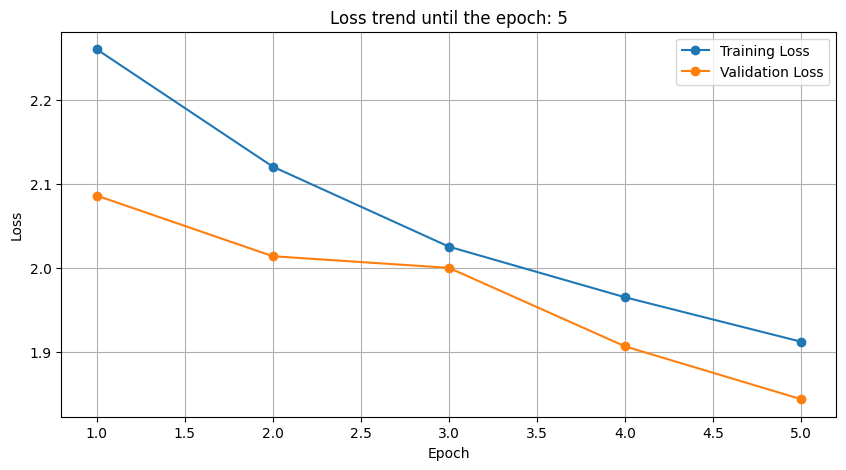

Epoch [6/60] | Train Loss: 1.8664 | Val Loss: 1.8161 | Val Acc: 38.25%
--> Improvement! Model saving... (Accuracy: 36.92% -> 38.25%)
Epoch [7/60] | Train Loss: 1.7982 | Val Loss: 1.7993 | Val Acc: 39.25%
--> Improvement! Model saving... (Accuracy: 38.25% -> 39.25%)
Epoch [8/60] | Train Loss: 1.7753 | Val Loss: 1.7136 | Val Acc: 41.92%
--> Improvement! Model saving... (Accuracy: 39.25% -> 41.92%)
Epoch [9/60] | Train Loss: 1.7025 | Val Loss: 1.7142 | Val Acc: 39.83%
Epoch [10/60] | Train Loss: 1.6789 | Val Loss: 1.5758 | Val Acc: 46.17%
--> Improvement! Model saving... (Accuracy: 41.92% -> 46.17%)


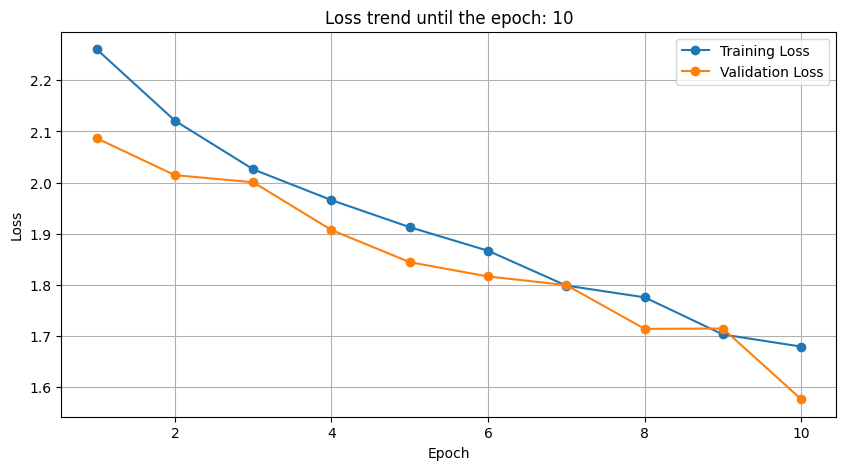

Epoch [11/60] | Train Loss: 1.6243 | Val Loss: 1.7154 | Val Acc: 40.50%
Epoch [12/60] | Train Loss: 1.5942 | Val Loss: 1.4926 | Val Acc: 48.58%
--> Improvement! Model saving... (Accuracy: 46.17% -> 48.58%)
Epoch [13/60] | Train Loss: 1.5530 | Val Loss: 1.5846 | Val Acc: 46.17%
Epoch [14/60] | Train Loss: 1.5205 | Val Loss: 1.5028 | Val Acc: 48.75%
--> Improvement! Model saving... (Accuracy: 48.58% -> 48.75%)
Epoch [15/60] | Train Loss: 1.4908 | Val Loss: 1.4247 | Val Acc: 50.83%
--> Improvement! Model saving... (Accuracy: 48.75% -> 50.83%)


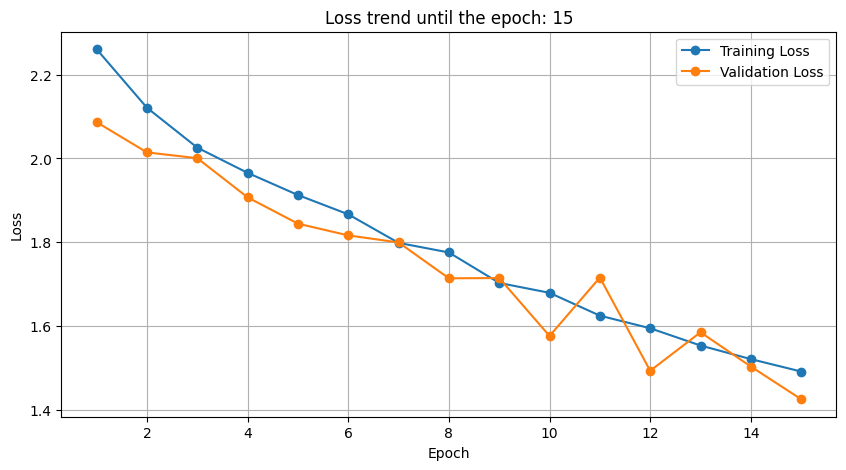

Epoch [16/60] | Train Loss: 1.4492 | Val Loss: 1.4643 | Val Acc: 50.33%
Epoch [17/60] | Train Loss: 1.4077 | Val Loss: 1.4464 | Val Acc: 51.42%
--> Improvement! Model saving... (Accuracy: 50.83% -> 51.42%)
Epoch [18/60] | Train Loss: 1.4055 | Val Loss: 1.3077 | Val Acc: 55.42%
--> Improvement! Model saving... (Accuracy: 51.42% -> 55.42%)
Epoch [19/60] | Train Loss: 1.3359 | Val Loss: 1.3670 | Val Acc: 53.83%
Epoch [20/60] | Train Loss: 1.3023 | Val Loss: 1.2996 | Val Acc: 57.58%
--> Improvement! Model saving... (Accuracy: 55.42% -> 57.58%)


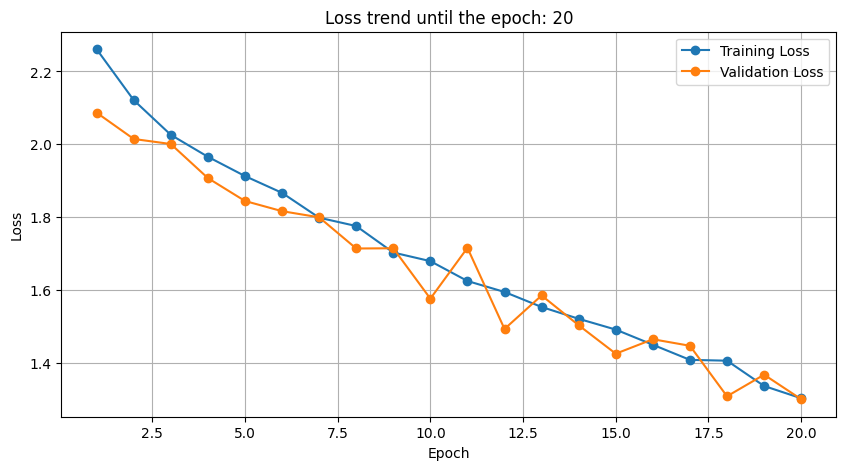

Epoch [21/60] | Train Loss: 1.2663 | Val Loss: 1.2694 | Val Acc: 58.67%
--> Improvement! Model saving... (Accuracy: 57.58% -> 58.67%)
Epoch [22/60] | Train Loss: 1.2297 | Val Loss: 1.2820 | Val Acc: 55.92%
Epoch [23/60] | Train Loss: 1.2003 | Val Loss: 1.2161 | Val Acc: 60.25%
--> Improvement! Model saving... (Accuracy: 58.67% -> 60.25%)
Epoch [24/60] | Train Loss: 1.1654 | Val Loss: 1.2029 | Val Acc: 62.17%
--> Improvement! Model saving... (Accuracy: 60.25% -> 62.17%)
Epoch [25/60] | Train Loss: 1.1495 | Val Loss: 1.2819 | Val Acc: 57.83%


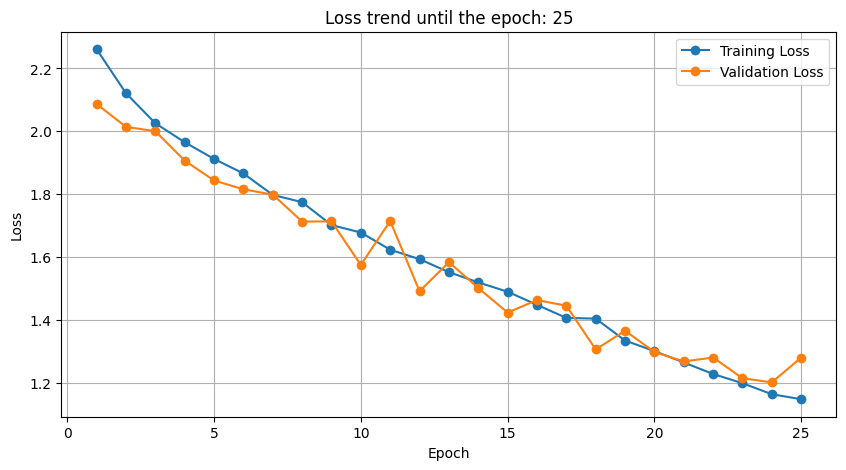

Epoch [26/60] | Train Loss: 1.0936 | Val Loss: 1.1238 | Val Acc: 61.92%
Epoch [27/60] | Train Loss: 1.0638 | Val Loss: 1.1814 | Val Acc: 62.00%
Epoch [28/60] | Train Loss: 1.0462 | Val Loss: 1.1053 | Val Acc: 62.33%
--> Improvement! Model saving... (Accuracy: 62.17% -> 62.33%)
Epoch [29/60] | Train Loss: 1.0054 | Val Loss: 1.0516 | Val Acc: 64.17%
--> Improvement! Model saving... (Accuracy: 62.33% -> 64.17%)
Epoch [30/60] | Train Loss: 0.9750 | Val Loss: 1.0552 | Val Acc: 64.08%


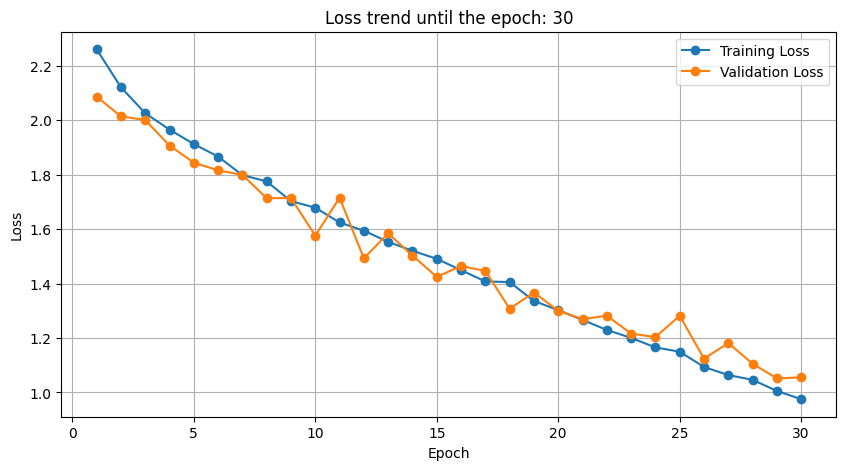

Epoch [31/60] | Train Loss: 0.9498 | Val Loss: 1.0798 | Val Acc: 65.33%
--> Improvement! Model saving... (Accuracy: 64.17% -> 65.33%)
Epoch [32/60] | Train Loss: 0.9190 | Val Loss: 1.0661 | Val Acc: 67.00%
--> Improvement! Model saving... (Accuracy: 65.33% -> 67.00%)
Epoch [33/60] | Train Loss: 0.8919 | Val Loss: 0.9823 | Val Acc: 67.92%
--> Improvement! Model saving... (Accuracy: 67.00% -> 67.92%)
Epoch [34/60] | Train Loss: 0.8683 | Val Loss: 1.0430 | Val Acc: 66.08%
Epoch [35/60] | Train Loss: 0.8494 | Val Loss: 1.0009 | Val Acc: 68.17%
--> Improvement! Model saving... (Accuracy: 67.92% -> 68.17%)


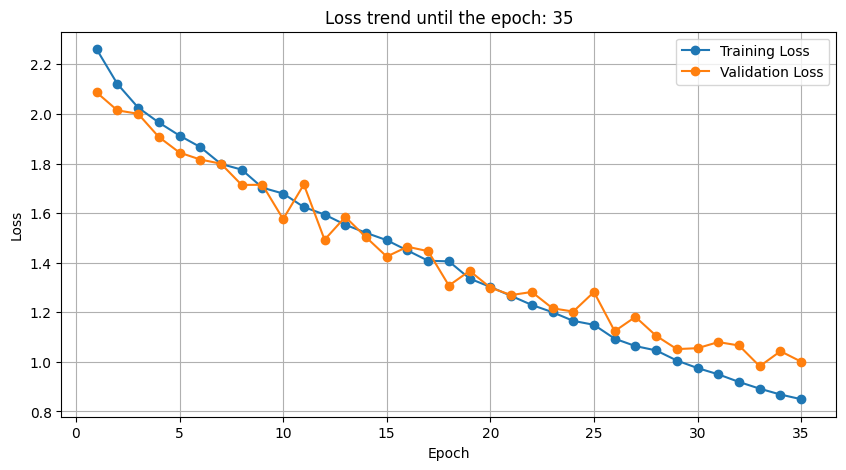

Epoch [36/60] | Train Loss: 0.8162 | Val Loss: 1.0495 | Val Acc: 66.92%
Epoch [37/60] | Train Loss: 0.8023 | Val Loss: 0.9546 | Val Acc: 69.25%
--> Improvement! Model saving... (Accuracy: 68.17% -> 69.25%)
Epoch [38/60] | Train Loss: 0.7514 | Val Loss: 0.9568 | Val Acc: 70.00%
--> Improvement! Model saving... (Accuracy: 69.25% -> 70.00%)
Epoch [39/60] | Train Loss: 0.7463 | Val Loss: 0.9316 | Val Acc: 70.42%
--> Improvement! Model saving... (Accuracy: 70.00% -> 70.42%)
Epoch [40/60] | Train Loss: 0.7219 | Val Loss: 0.9237 | Val Acc: 69.75%


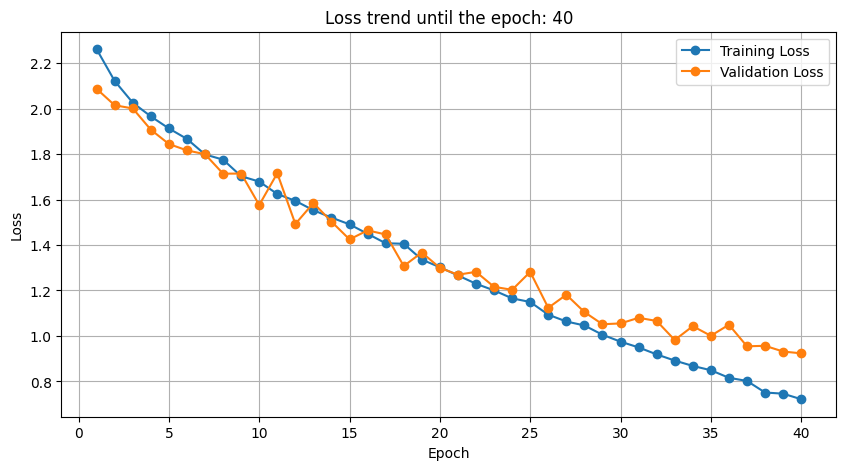

Epoch [41/60] | Train Loss: 0.6969 | Val Loss: 0.8801 | Val Acc: 72.25%
--> Improvement! Model saving... (Accuracy: 70.42% -> 72.25%)
Epoch [42/60] | Train Loss: 0.6920 | Val Loss: 0.8738 | Val Acc: 72.67%
--> Improvement! Model saving... (Accuracy: 72.25% -> 72.67%)
Epoch [43/60] | Train Loss: 0.6618 | Val Loss: 0.9011 | Val Acc: 72.33%
Epoch [44/60] | Train Loss: 0.6575 | Val Loss: 0.8571 | Val Acc: 73.42%
--> Improvement! Model saving... (Accuracy: 72.67% -> 73.42%)
Epoch [45/60] | Train Loss: 0.6346 | Val Loss: 0.8614 | Val Acc: 72.83%


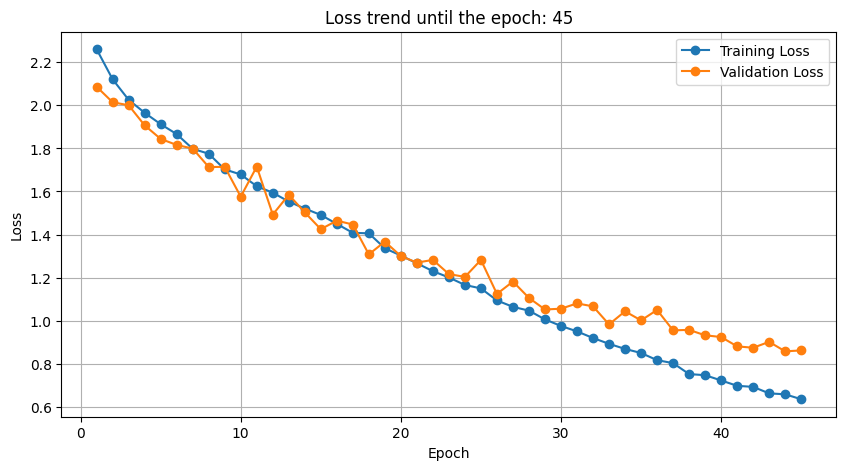

Epoch [46/60] | Train Loss: 0.6030 | Val Loss: 0.8257 | Val Acc: 74.08%
--> Improvement! Model saving... (Accuracy: 73.42% -> 74.08%)
Epoch [47/60] | Train Loss: 0.6064 | Val Loss: 0.8338 | Val Acc: 74.42%
--> Improvement! Model saving... (Accuracy: 74.08% -> 74.42%)
Epoch [48/60] | Train Loss: 0.5964 | Val Loss: 0.8423 | Val Acc: 73.75%
Epoch [49/60] | Train Loss: 0.5628 | Val Loss: 0.8023 | Val Acc: 74.25%
Epoch [50/60] | Train Loss: 0.5570 | Val Loss: 0.8172 | Val Acc: 74.33%


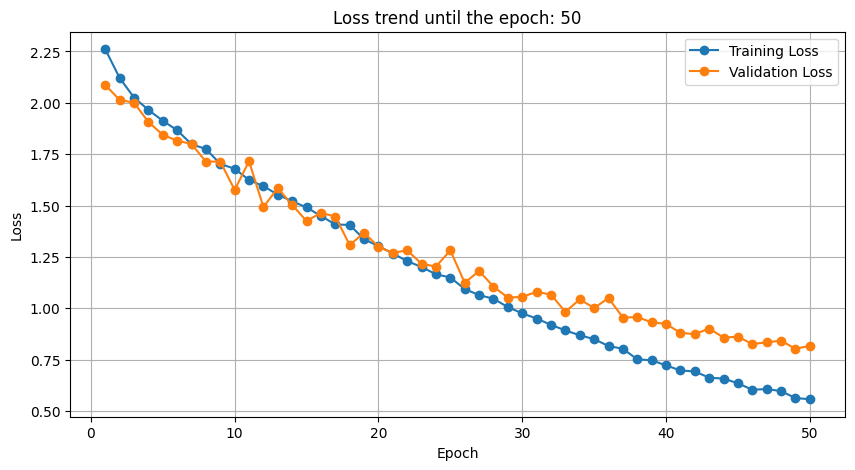

Epoch [51/60] | Train Loss: 0.5643 | Val Loss: 0.8196 | Val Acc: 74.42%
Epoch [52/60] | Train Loss: 0.5472 | Val Loss: 0.8028 | Val Acc: 75.00%
--> Improvement! Model saving... (Accuracy: 74.42% -> 75.00%)
Epoch [53/60] | Train Loss: 0.5488 | Val Loss: 0.8025 | Val Acc: 74.83%
Epoch [54/60] | Train Loss: 0.5281 | Val Loss: 0.8015 | Val Acc: 75.25%
--> Improvement! Model saving... (Accuracy: 75.00% -> 75.25%)
Epoch [55/60] | Train Loss: 0.5317 | Val Loss: 0.7925 | Val Acc: 75.58%
--> Improvement! Model saving... (Accuracy: 75.25% -> 75.58%)


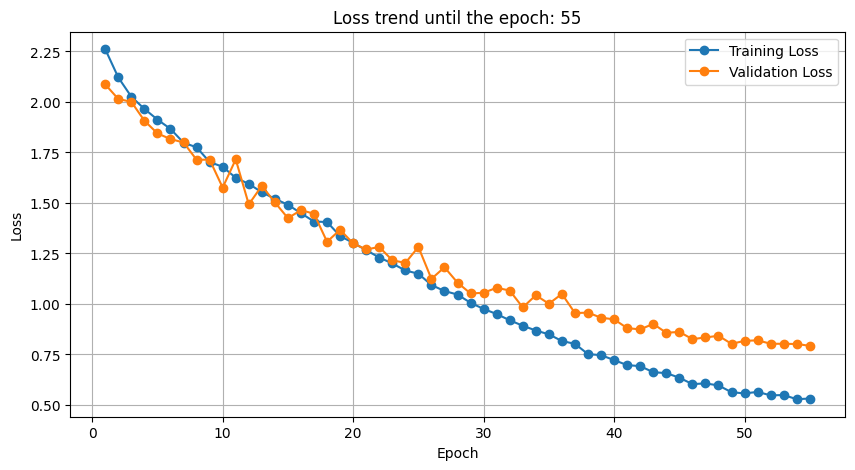

Epoch [56/60] | Train Loss: 0.5368 | Val Loss: 0.7857 | Val Acc: 75.75%
--> Improvement! Model saving... (Accuracy: 75.58% -> 75.75%)
Epoch [57/60] | Train Loss: 0.5226 | Val Loss: 0.7989 | Val Acc: 74.83%
Epoch [58/60] | Train Loss: 0.5083 | Val Loss: 0.7910 | Val Acc: 75.75%
Epoch [59/60] | Train Loss: 0.5046 | Val Loss: 0.8001 | Val Acc: 74.92%
Epoch [60/60] | Train Loss: 0.5090 | Val Loss: 0.7881 | Val Acc: 75.83%
--> Improvement! Model saving... (Accuracy: 75.75% -> 75.83%)


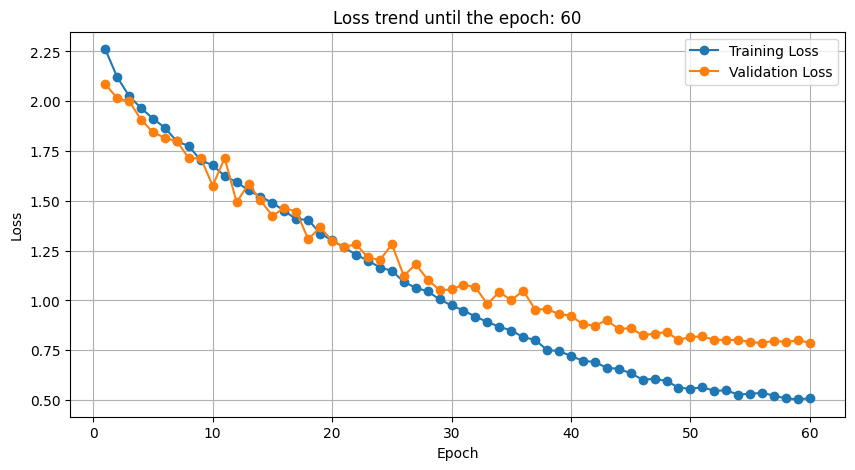

------------------------------
Trained completed! Best accuracy reached: 75.83%
Model saved in: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth


In [ ]:
import matplotlib.pyplot as plt
import torch
import os
import torch.optim as optim
from IPython.display import clear_output

folder_path = '/content/drive/MyDrive/Deep_learning'
save_path = os.path.join(folder_path, 'best_mushroom_model.pth')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
best_val_acc = 0.0
train_losses = []
val_losses = []



print(f"Start the train on {device}...")
print(f"The best model would be saved on: {save_path}")


# TRAIN
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

  # VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    # PLOT
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")

#***Model 2D***
***


We integrated Test-Time Augmentation (TTA) by averaging predictions from original and horizontally flipped images during validation. This technique increases the model's robustness to orientation and helped us achieve a significantly higher final accuracy.




Start the train on cuda...
The best model would be saved on: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth
Epoch [1/60] | Train Loss: 1.5545 | Val Loss: 1.4842 | Val Acc: 49.50%
--> Improvement! Model saving... (Accuracy: 0.00% -> 49.50%)
Epoch [2/60] | Train Loss: 1.5263 | Val Loss: 1.4534 | Val Acc: 49.50%
Epoch [3/60] | Train Loss: 1.4894 | Val Loss: 1.4592 | Val Acc: 50.67%
--> Improvement! Model saving... (Accuracy: 49.50% -> 50.67%)
Epoch [4/60] | Train Loss: 1.4361 | Val Loss: 1.4033 | Val Acc: 53.42%
--> Improvement! Model saving... (Accuracy: 50.67% -> 53.42%)
Epoch [5/60] | Train Loss: 1.4198 | Val Loss: 1.4014 | Val Acc: 54.83%
--> Improvement! Model saving... (Accuracy: 53.42% -> 54.83%)


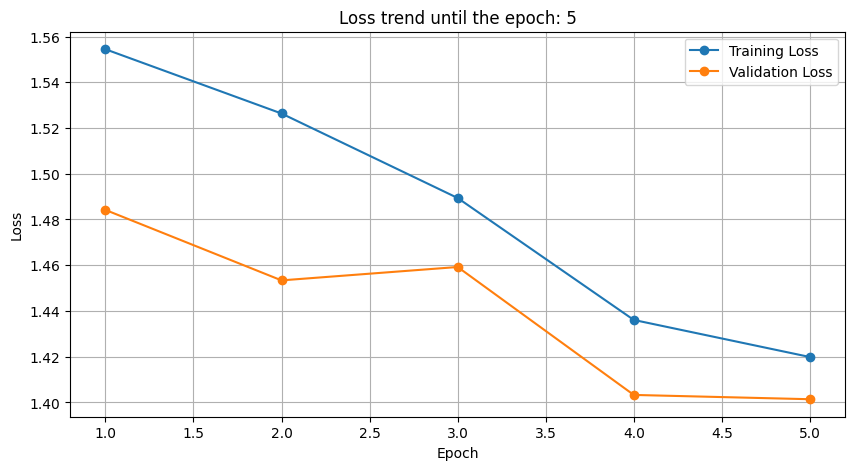

Epoch [6/60] | Train Loss: 1.3760 | Val Loss: 1.3293 | Val Acc: 54.83%
Epoch [7/60] | Train Loss: 1.3493 | Val Loss: 1.3456 | Val Acc: 54.58%
Epoch [8/60] | Train Loss: 1.3002 | Val Loss: 1.2857 | Val Acc: 55.58%
--> Improvement! Model saving... (Accuracy: 54.83% -> 55.58%)
Epoch [9/60] | Train Loss: 1.2685 | Val Loss: 1.2033 | Val Acc: 60.67%
--> Improvement! Model saving... (Accuracy: 55.58% -> 60.67%)
Epoch [10/60] | Train Loss: 1.2467 | Val Loss: 1.2346 | Val Acc: 60.25%


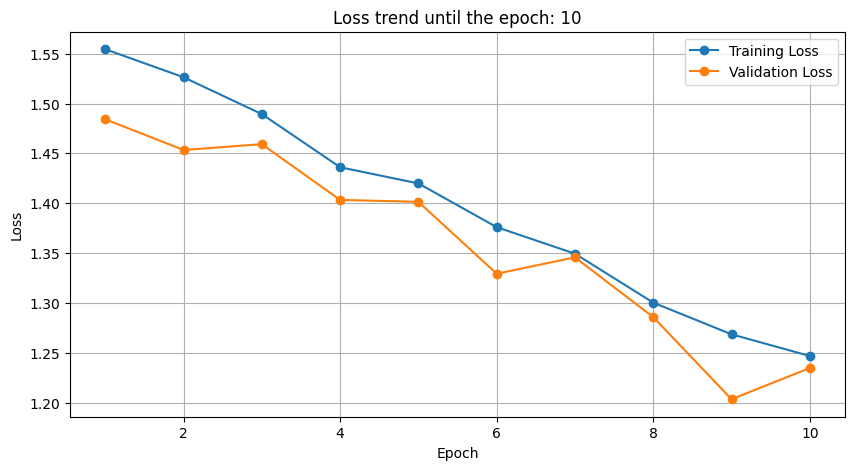

Epoch [11/60] | Train Loss: 1.2000 | Val Loss: 1.1623 | Val Acc: 62.25%
--> Improvement! Model saving... (Accuracy: 60.67% -> 62.25%)
Epoch [12/60] | Train Loss: 1.1711 | Val Loss: 1.1885 | Val Acc: 60.75%
Epoch [13/60] | Train Loss: 1.1491 | Val Loss: 1.1173 | Val Acc: 61.42%
Epoch [14/60] | Train Loss: 1.1231 | Val Loss: 1.1060 | Val Acc: 63.08%
--> Improvement! Model saving... (Accuracy: 62.25% -> 63.08%)
Epoch [15/60] | Train Loss: 1.0830 | Val Loss: 1.0569 | Val Acc: 62.75%


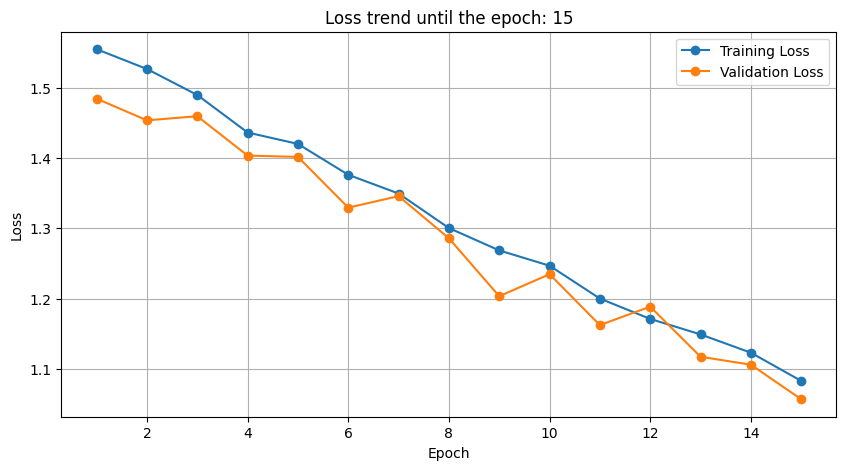

Epoch [16/60] | Train Loss: 1.0481 | Val Loss: 1.1793 | Val Acc: 60.92%
Epoch [17/60] | Train Loss: 1.0191 | Val Loss: 1.0313 | Val Acc: 65.92%
--> Improvement! Model saving... (Accuracy: 63.08% -> 65.92%)
Epoch [18/60] | Train Loss: 0.9866 | Val Loss: 1.0190 | Val Acc: 67.25%
--> Improvement! Model saving... (Accuracy: 65.92% -> 67.25%)
Epoch [19/60] | Train Loss: 0.9671 | Val Loss: 1.1227 | Val Acc: 62.75%
Epoch [20/60] | Train Loss: 0.9395 | Val Loss: 0.9550 | Val Acc: 68.83%
--> Improvement! Model saving... (Accuracy: 67.25% -> 68.83%)


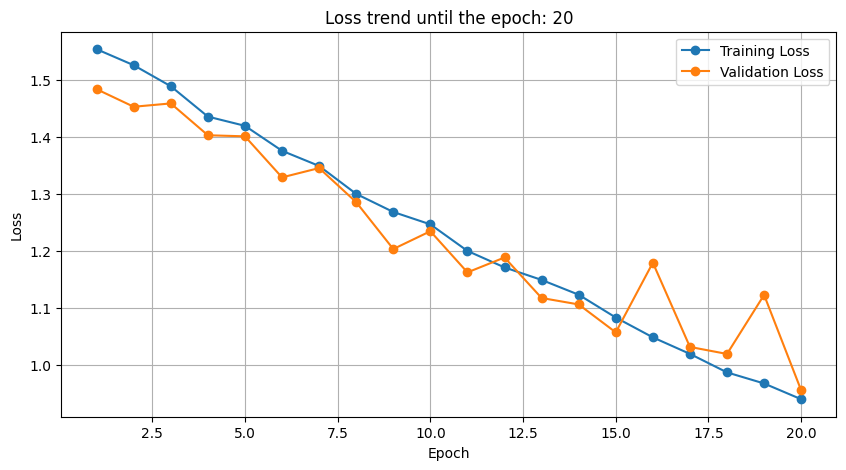

Epoch [21/60] | Train Loss: 0.9052 | Val Loss: 0.9541 | Val Acc: 67.75%
Epoch [22/60] | Train Loss: 0.8825 | Val Loss: 0.9689 | Val Acc: 69.17%
--> Improvement! Model saving... (Accuracy: 68.83% -> 69.17%)
Epoch [23/60] | Train Loss: 0.8614 | Val Loss: 0.9898 | Val Acc: 67.67%
Epoch [24/60] | Train Loss: 0.8424 | Val Loss: 0.9390 | Val Acc: 68.00%
Epoch [25/60] | Train Loss: 0.8183 | Val Loss: 0.9525 | Val Acc: 68.00%


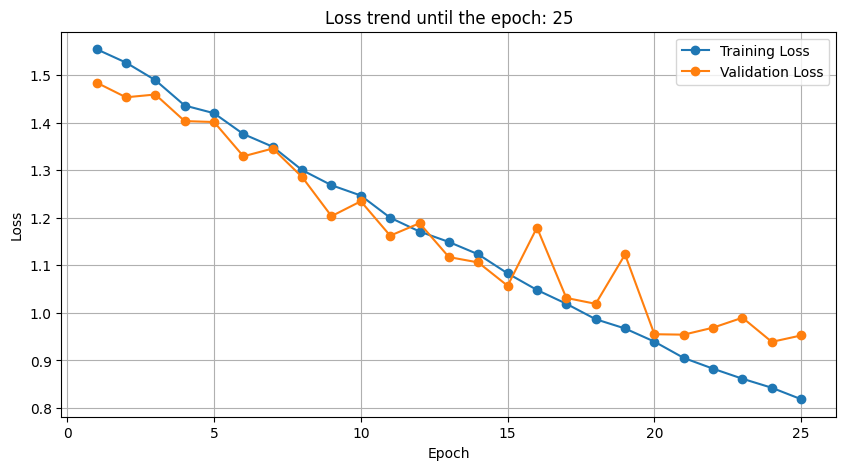

Epoch [26/60] | Train Loss: 0.7896 | Val Loss: 0.8635 | Val Acc: 72.67%
--> Improvement! Model saving... (Accuracy: 69.17% -> 72.67%)
Epoch [27/60] | Train Loss: 0.7826 | Val Loss: 0.8372 | Val Acc: 73.50%
--> Improvement! Model saving... (Accuracy: 72.67% -> 73.50%)
Epoch [28/60] | Train Loss: 0.7434 | Val Loss: 0.8696 | Val Acc: 71.67%
Epoch [29/60] | Train Loss: 0.7346 | Val Loss: 0.8359 | Val Acc: 73.08%
Epoch [30/60] | Train Loss: 0.7019 | Val Loss: 0.8150 | Val Acc: 73.75%
--> Improvement! Model saving... (Accuracy: 73.50% -> 73.75%)


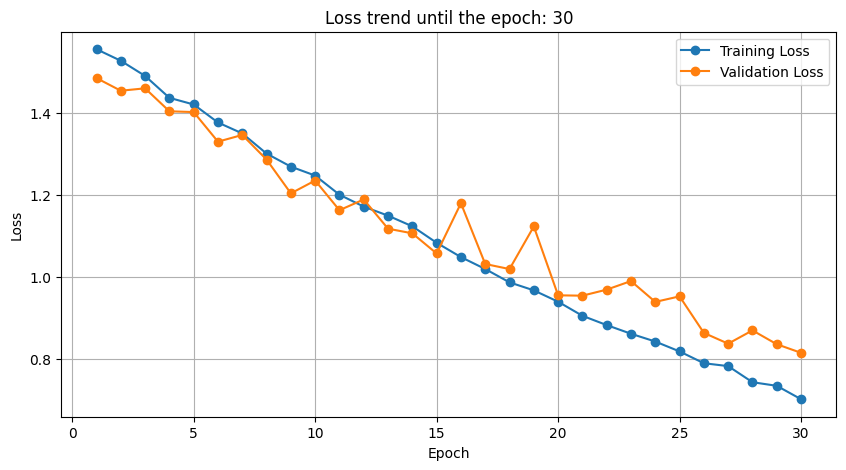

Epoch [31/60] | Train Loss: 0.7075 | Val Loss: 0.7838 | Val Acc: 75.17%
--> Improvement! Model saving... (Accuracy: 73.75% -> 75.17%)
Epoch [32/60] | Train Loss: 0.6880 | Val Loss: 0.8002 | Val Acc: 73.92%
Epoch [33/60] | Train Loss: 0.6499 | Val Loss: 0.7601 | Val Acc: 75.33%
--> Improvement! Model saving... (Accuracy: 75.17% -> 75.33%)
Epoch [34/60] | Train Loss: 0.6467 | Val Loss: 0.7684 | Val Acc: 75.25%
Epoch [35/60] | Train Loss: 0.6300 | Val Loss: 0.7568 | Val Acc: 76.33%
--> Improvement! Model saving... (Accuracy: 75.33% -> 76.33%)


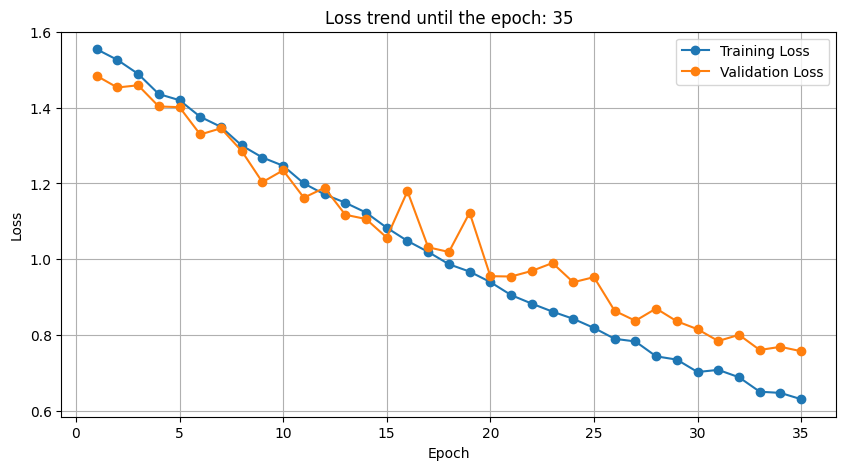

Epoch [36/60] | Train Loss: 0.6103 | Val Loss: 0.7533 | Val Acc: 75.67%
Epoch [37/60] | Train Loss: 0.6188 | Val Loss: 0.7551 | Val Acc: 75.75%
Epoch [38/60] | Train Loss: 0.6143 | Val Loss: 0.7454 | Val Acc: 76.25%
Epoch [39/60] | Train Loss: 0.5842 | Val Loss: 0.7433 | Val Acc: 76.67%
--> Improvement! Model saving... (Accuracy: 76.33% -> 76.67%)
Epoch [40/60] | Train Loss: 0.5905 | Val Loss: 0.7272 | Val Acc: 76.67%


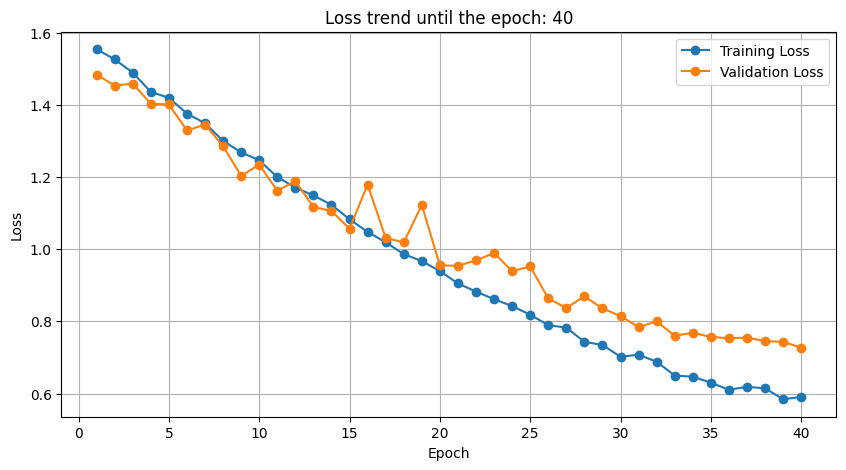

Epoch [41/60] | Train Loss: 0.5710 | Val Loss: 0.7300 | Val Acc: 76.67%
Epoch [42/60] | Train Loss: 0.5764 | Val Loss: 0.7143 | Val Acc: 77.08%
--> Improvement! Model saving... (Accuracy: 76.67% -> 77.08%)
Epoch [43/60] | Train Loss: 0.5759 | Val Loss: 0.7325 | Val Acc: 77.08%
Epoch [44/60] | Train Loss: 0.5625 | Val Loss: 0.7231 | Val Acc: 77.17%
--> Improvement! Model saving... (Accuracy: 77.08% -> 77.17%)
Epoch [45/60] | Train Loss: 0.5619 | Val Loss: 0.7163 | Val Acc: 77.08%


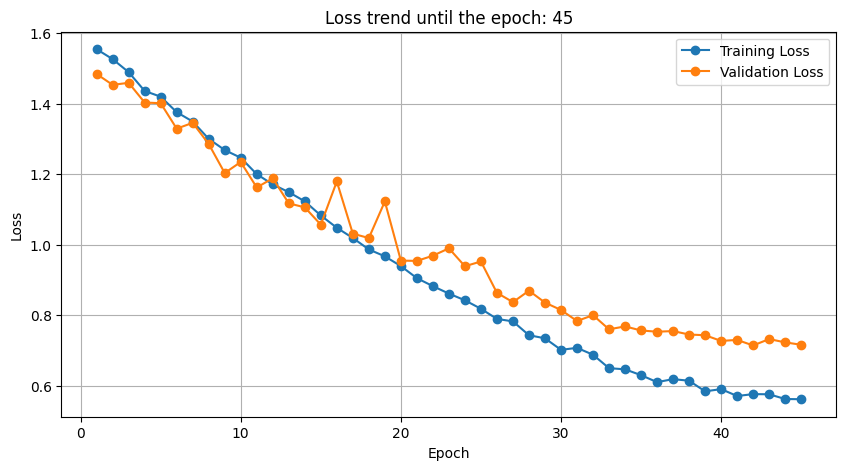

Epoch [46/60] | Train Loss: 0.5676 | Val Loss: 0.7280 | Val Acc: 76.50%
Epoch [47/60] | Train Loss: 0.5557 | Val Loss: 0.7252 | Val Acc: 76.42%
Epoch [48/60] | Train Loss: 0.5503 | Val Loss: 0.7285 | Val Acc: 76.17%
Epoch [49/60] | Train Loss: 0.5539 | Val Loss: 0.7193 | Val Acc: 76.42%
Epoch [50/60] | Train Loss: 0.5515 | Val Loss: 0.7119 | Val Acc: 77.00%


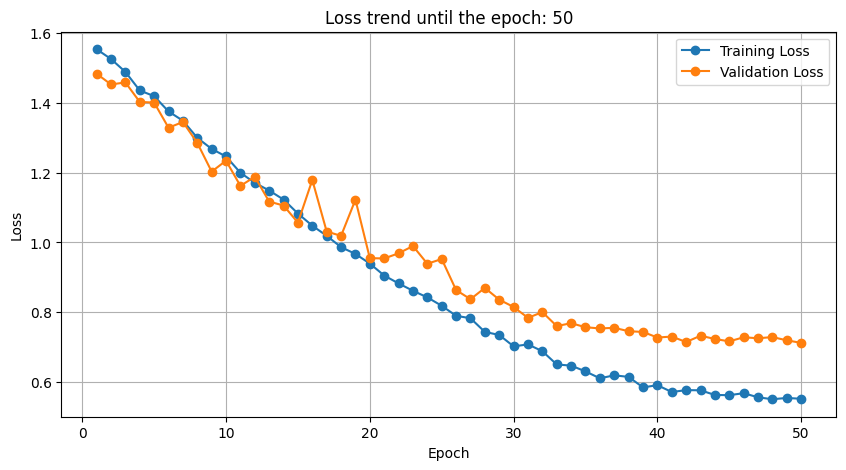

Epoch [51/60] | Train Loss: 0.5535 | Val Loss: 0.7166 | Val Acc: 77.42%
--> Improvement! Model saving... (Accuracy: 77.17% -> 77.42%)
Epoch [52/60] | Train Loss: 0.5590 | Val Loss: 0.7169 | Val Acc: 76.67%
Epoch [53/60] | Train Loss: 0.5532 | Val Loss: 0.7200 | Val Acc: 76.67%
Epoch [54/60] | Train Loss: 0.5642 | Val Loss: 0.7191 | Val Acc: 77.25%
Epoch [55/60] | Train Loss: 0.5699 | Val Loss: 0.7098 | Val Acc: 77.42%


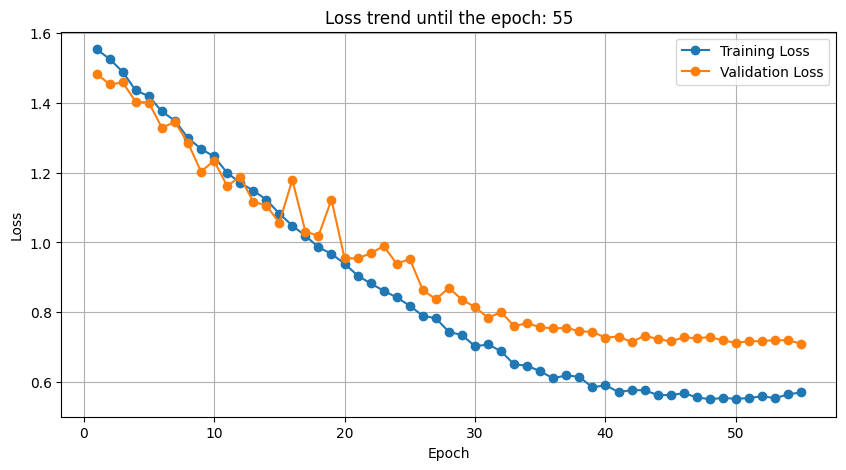

Epoch [56/60] | Train Loss: 0.5547 | Val Loss: 0.7316 | Val Acc: 76.58%
Epoch [57/60] | Train Loss: 0.5594 | Val Loss: 0.7194 | Val Acc: 77.08%
Epoch [58/60] | Train Loss: 0.5559 | Val Loss: 0.7128 | Val Acc: 77.25%
Epoch [59/60] | Train Loss: 0.5560 | Val Loss: 0.7248 | Val Acc: 77.08%
Epoch [60/60] | Train Loss: 0.5764 | Val Loss: 0.7276 | Val Acc: 75.50%


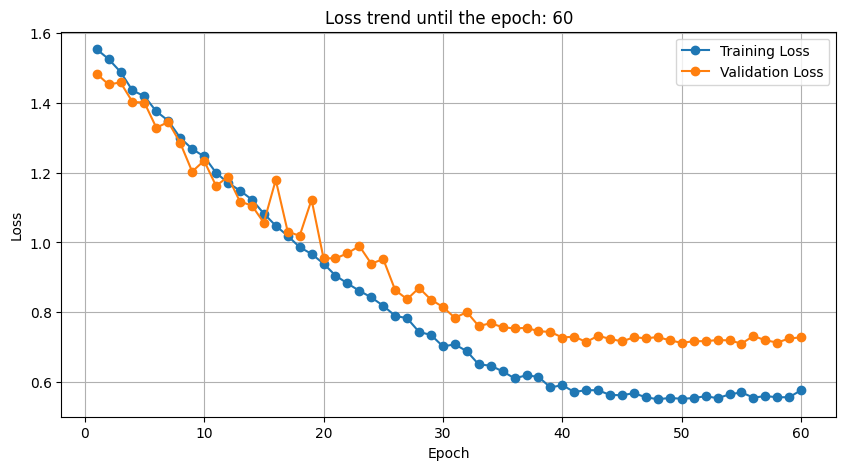

------------------------------
Trained completed! Best accuracy reached: 77.42%
Model saved in: /content/drive/MyDrive/Deep_learning/best_mushroom_model.pth


In [ ]:
import matplotlib.pyplot as plt
import torch
import os
import torch.optim as optim
from IPython.display import clear_output

folder_path = '/content/drive/MyDrive/Deep_learning'
save_path = os.path.join(folder_path, 'best_mushroom_model.pth')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
best_val_acc = 0.0
train_losses = []
val_losses = []



print(f"Start the train on {device}...")
print(f"The best model would be saved on: {save_path}")


# TRAIN
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

# VALIDATION con Test-Time Augmentation (TTA)
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # --- INIZIO TTA ---
            # 1. Calcoliamo le previsioni sull'immagine ORIGINALE
            outputs_orig = model(images)

            # 2. Creiamo l'immagine SPECCHIATA (flip sulla dimensione della larghezza, la 3)
            images_flipped = torch.flip(images, dims=[3])

            # 3. Calcoliamo le previsioni sull'immagine specchiata
            outputs_flipped = model(images_flipped)

            # 4. Facciamo la MEDIA matematica delle due previsioni
            outputs = (outputs_orig + outputs_flipped) / 2.0
            # --- FINE TTA ---

            # Il resto del codice rimane IDENTICO a prima!
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step() # Ricordati che avevamo tolto avg_val_loss da qui per il CosineAnnealing!

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    # PLOT
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")